In [1]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
model = joblib.load("../models/xgboost_v1.pkl")
feature_importances = pd.read_csv("../models/info/xgboost_v1/xgboost_v1_features.csv", index_col="feature")
mae_by_horizon = pd.read_csv("../models/info/xgboost_v1/xgboost_v1_mae_by_horizon.csv")
mae_by_month = pd.read_csv("../models/info/xgboost_v1/xgboost_v1_mae_by_month.csv")

In [3]:
feature_importances.sort_values(by="importance", ascending=False).head(20)

,importance
feature,
price,0.203525
wind_speed_100m_Soria_Wind,0.045079
rolling_1w_mean,0.044976
target_hour,0.040292
rolling_24h_mean,0.028997
wind_speed_100m_Navarra_Wind,0.025720
wind_speed_100m_Alicante_Solar,0.025278
demand,0.024778
target_weekday,0.023256


In [19]:
groups = {
    "cities": feature_importances[
        feature_importances.index.str.contains("City")
    ],
    "wind": feature_importances[
        feature_importances.index.str.contains("Wind")
    ],
    "solar": feature_importances[
        feature_importances.index.str.contains("Solar")
    ]    
}

group_importance = (
    pd.Series({
        "cities": groups["cities"]["importance"].mean(),
        "wind": groups["wind"]["importance"].mean(),
        "solar": groups["solar"]["importance"].mean()
    })
    .sort_values(ascending=False)
)

print(
    100 * group_importance / group_importance.sum()
)

wind      37.654064
solar     33.083623
cities    29.262312
dtype: float64


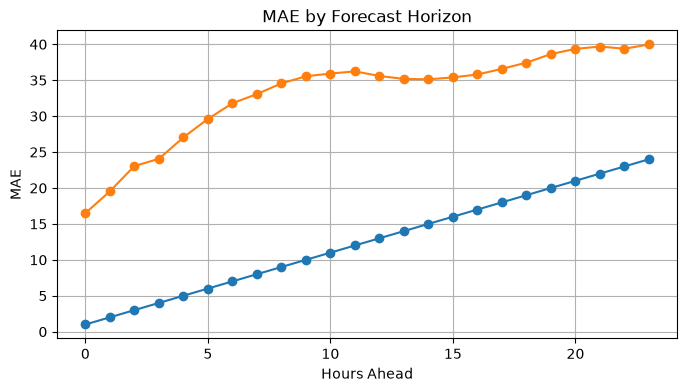

In [4]:
plt.figure(figsize=(8, 4))
plt.plot(
    mae_by_horizon.index,
    mae_by_horizon.values,
    marker="o"
)

plt.xlabel("Hours Ahead")
plt.ylabel("MAE")
plt.title("MAE by Forecast Horizon")
plt.grid(True)
plt.show()

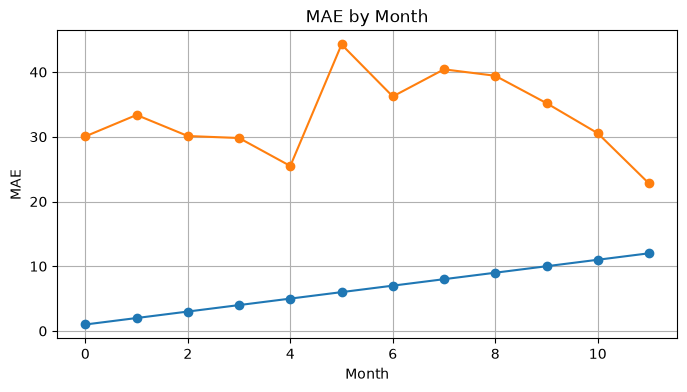

In [5]:
plt.figure(figsize=(8, 4))
plt.plot(
    mae_by_month.index,
    mae_by_month.values,
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("MAE")
plt.title("MAE by Month")
plt.grid(True)
plt.show()